# EchoMind — Prosody v5 Kaggle Emotions ADVANCED FIXED

Notebook potente para treinar uma nova prosódia com o dataset **Emotions** do Kaggle, juntando **RAVDESS + CREMA-D + SAVEE + TESS**.

Versão corrigida após EDA inicial:

- remove automaticamente ficheiros com `source_dataset == 'unknown'`;
- força validação das **7 emoções** do EchoMind;
- bloqueia o treino se alguma emoção estiver ausente, para evitar treinar um modelo incompatível com o multimodal;
- mostra claramente pastas encontradas, ficheiros removidos e distribuição final usada;
- mantém speaker/source inference, features manuais, WavLM e avaliação por grupos.



## 1. Instalação

In [1]:
import sys, subprocess
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-U',
    'numpy', 'pandas', 'matplotlib', 'tqdm', 'joblib',
    'scikit-learn', 'librosa', 'soundfile', 'torch',
    'transformers', 'accelerate', 'praat-parselmouth'
])


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


0

## 2. Imports e configuração

In [2]:
from __future__ import annotations
import re, json, time, hashlib, warnings
from pathlib import Path
from collections import Counter
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import joblib

import librosa
import sklearn
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedGroupKFold, GroupKFold

try:
    import parselmouth
    HAS_PRAAT = True
except Exception as e:
    HAS_PRAAT = False
    print('Praat/parselmouth indisponível:', repr(e))

warnings.filterwarnings('ignore')

# Caminho esperado segundo a tua imagem.
DATASET_DIR = Path.cwd() / 'Emotions'
OUTPUT_DIR = Path('prosody_outputs_v5')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

USE_CACHE = True
MAX_FILES_FOR_DEBUG = None       # põe 500 para testar rápido; None para treino final

# Controlo de limpeza/validação do dataset
DROP_UNKNOWN_SOURCE = True        # remove os 10 ficheiros unknown que viste na EDA
FORCE_REBUILD_METADATA = True     # evita carregar cache antiga sem Surprised, caso corrijas a pasta
REQUIRE_ALL_EMOTIONS = True       # objetivo do EchoMind = 7 emoções; não treinar se faltar alguma
MIN_SAMPLES_PER_EMOTION = 1
RUN_MANUAL_FEATURES = True
RUN_SSL_EMBEDDINGS = True

SSL_MODEL_NAME = 'microsoft/wavlm-base'
SSL_SAMPLE_RATE = 16000
SSL_MAX_SECONDS_PER_CHUNK = 12.0
SSL_CHUNK_OVERLAP_SECONDS = 1.0

RANDOM_STATE = 42
N_SPLITS_GROUP_CV = 5

EMOTIONS = ['joy','sadness','surprise','fear','anger','disgust','neutral']
FOLDER_LABEL_MAP = {
    'Angry':'anger', 'Happy':'joy', 'Sad':'sadness', 'Neutral':'neutral',
    'Fearful':'fear', 'Disgusted':'disgust', 'Surprised':'surprise', 'Suprised':'surprise',
    'angry':'anger', 'happy':'joy', 'sad':'sadness', 'neutral':'neutral',
    'fearful':'fear', 'disgusted':'disgust', 'surprised':'surprise', 'suprised':'surprise',
    'anger':'anger', 'joy':'joy', 'sadness':'sadness', 'fear':'fear',
    'disgust':'disgust', 'surprise':'surprise'
}

print('DATASET_DIR:', DATASET_DIR.resolve())
print('Existe?', DATASET_DIR.exists())
print('sklearn:', sklearn.__version__)


/home/tomas/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/home/tomas/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DATASET_DIR: /home/tomas/MIA/1ANO/2SEM/CA/CA-25_26/tests/prosody/Emotions
Existe? True
sklearn: 1.7.2


## 3. Metadata: labels, origem e speaker

In [3]:
def infer_source_and_speaker(path: Path) -> Tuple[str, str]:
    stem = path.stem

    # RAVDESS: 03-01-05-01-01-01-01.wav
    if re.match(r'^\d{2}-\d{2}-\d{2}-\d{2}-\d{2}-\d{2}-\d{2}$', stem):
        actor = stem.split('-')[-1]
        return 'RAVDESS', f'RAVDESS_actor_{actor}'

    # CREMA-D: 1003_IOM_ANG_XX.wav
    if re.match(r'^\d{4}_[A-Z]{3}_[A-Z]{3}_[A-Z]{2}$', stem):
        actor = stem.split('_')[0]
        return 'CREMA-D', f'CREMA_actor_{actor}'

    # TESS: OAF_word_angry.wav / YAF_word_happy.wav
    if stem.startswith('OAF_'):
        return 'TESS', 'TESS_OAF'
    if stem.startswith('YAF_'):
        return 'TESS', 'TESS_YAF'

    # SAVEE-like: a01.wav, d01.wav, f01.wav, h01.wav, n01.wav, sa01.wav, su01.wav
    if re.match(r'^[a-z]{1,2}\d{2}$', stem):
        return 'SAVEE', 'SAVEE_unknown'

    return 'unknown', 'unknown'


def label_from_folder(path: Path, root: Path) -> Optional[str]:
    """Obtém label a partir da primeira pasta dentro de DATASET_DIR.
    Ex.: Emotions/Angry/x.wav -> anger
    """
    try:
        folder = path.relative_to(root).parts[0]
    except Exception:
        folder = path.parent.name
    return FOLDER_LABEL_MAP.get(folder, FOLDER_LABEL_MAP.get(folder.lower()))


def file_hash(path: Path) -> str:
    st = path.stat()
    raw = f'{path.resolve()}|{st.st_size}|{st.st_mtime}'.encode('utf-8')
    return hashlib.md5(raw).hexdigest()


def show_dataset_folders(dataset_dir: Path):
    print('Pastas de topo encontradas em DATASET_DIR:')
    if not dataset_dir.exists():
        print('  DATASET_DIR não existe:', dataset_dir)
        return []
    folders = sorted([p for p in dataset_dir.iterdir() if p.is_dir()], key=lambda p: p.name.lower())
    for p in folders:
        n_audio = sum(1 for x in p.rglob('*') if x.suffix.lower() in {'.wav','.mp3','.flac','.ogg','.m4a'})
        mapped = FOLDER_LABEL_MAP.get(p.name, FOLDER_LABEL_MAP.get(p.name.lower()))
        print(f'  {p.name:<20} -> {mapped} | {n_audio} ficheiros áudio')
    return folders


def build_metadata(dataset_dir: Path, max_files: Optional[int] = None) -> pd.DataFrame:
    exts = {'.wav','.mp3','.flac','.ogg','.m4a'}
    files = sorted([p for p in dataset_dir.rglob('*') if p.suffix.lower() in exts])
    if max_files is not None:
        files = files[:max_files]

    rows = []
    skipped_label = []
    for p in files:
        label = label_from_folder(p, dataset_dir)
        if label not in EMOTIONS:
            skipped_label.append(str(p))
            continue
        src, spk = infer_source_and_speaker(p)
        rows.append({
            'path': str(p.resolve()),
            'filename': p.name,
            'folder': p.relative_to(dataset_dir).parts[0] if dataset_dir in p.parents else p.parent.name,
            'label': label,
            'source_dataset': src,
            'speaker': spk,
            'file_hash': file_hash(p)
        })

    df = pd.DataFrame(rows)
    if skipped_label:
        print(f'⚠️ {len(skipped_label)} ficheiros ignorados por pasta/label não reconhecida.')
        print('Exemplos:', skipped_label[:10])
    return df


def validate_and_clean_metadata(metadata: pd.DataFrame) -> pd.DataFrame:
    print('\n--- Validação e limpeza do metadata ---')
    print('Ficheiros antes da limpeza:', len(metadata))

    if metadata.empty:
        raise RuntimeError('Metadata vazio. Confirma DATASET_DIR e estrutura Emotions/<Emotion>/*.wav')

    # Remover unknown source, como pediste.
    if DROP_UNKNOWN_SOURCE:
        unknown_mask = metadata['source_dataset'].eq('unknown') | metadata['speaker'].eq('unknown')
        n_unknown = int(unknown_mask.sum())
        if n_unknown:
            print(f'🧹 A remover {n_unknown} ficheiros com source/speaker unknown.')
            display(metadata.loc[unknown_mask, ['filename','folder','label','source_dataset','speaker']].head(20))
        metadata = metadata.loc[~unknown_mask].copy()

    # Ver distribuição com todas as emoções, incluindo zeros.
    counts = metadata['label'].value_counts().reindex(EMOTIONS, fill_value=0)
    print('\nDistribuição final por emoção:')
    display(counts.to_frame('n'))

    missing = counts[counts < MIN_SAMPLES_PER_EMOTION].index.tolist()
    if missing:
        msg = (
            '❌ Faltam emoções no dataset carregado: ' + ', '.join(missing) + '\n'
            'No teu caso a EDA anterior mostrava surprise=0, o que significa que a pasta Surprised '
            'não foi encontrada/carregada. O objetivo do EchoMind são 7 emoções; treinar sem surprise '
            'gera um modelo incompatível com a fusão final.\n\n'
            'Confirma se existe algo como Emotions/Surprised/*.wav ou Emotions/Surprise/*.wav. '
            'Depois volta a correr este notebook desde o início.\n'
            'Se quiseres ignorar isto apenas para debug, muda REQUIRE_ALL_EMOTIONS=False, mas não uses esse modelo como final.'
        )
        if REQUIRE_ALL_EMOTIONS:
            raise RuntimeError(msg)
        else:
            print(msg)

    print('Ficheiros depois da limpeza:', len(metadata))
    print('Sources finais:')
    display(metadata['source_dataset'].value_counts().to_frame('n'))
    print('Nº speakers finais:', metadata['speaker'].nunique())

    return metadata.reset_index(drop=True)


show_dataset_folders(DATASET_DIR)

metadata_path = OUTPUT_DIR / 'metadata_v5_clean.csv'
if USE_CACHE and metadata_path.exists() and not FORCE_REBUILD_METADATA:
    metadata = pd.read_csv(metadata_path)
else:
    metadata = build_metadata(DATASET_DIR, MAX_FILES_FOR_DEBUG)
    metadata = validate_and_clean_metadata(metadata)
    metadata.to_csv(metadata_path, index=False)

# Mesmo quando vem da cache, validar/limpar novamente para segurança.
metadata = validate_and_clean_metadata(metadata)
metadata.to_csv(metadata_path, index=False)

print('\nNº ficheiros finais:', len(metadata))
display(metadata.head())
print('\nLabels:')
print(metadata['label'].value_counts().reindex(EMOTIONS, fill_value=0))
print('\nSource datasets:')
print(metadata['source_dataset'].value_counts())
print('\nNº speakers:', metadata['speaker'].nunique())
print(metadata['speaker'].value_counts().head(15))


Pastas de topo encontradas em DATASET_DIR:
  Angry                -> anger | 2167 ficheiros áudio
  Disgusted            -> disgust | 1863 ficheiros áudio
  Fearful              -> fear | 2047 ficheiros áudio
  Happy                -> joy | 2167 ficheiros áudio
  Neutral              -> neutral | 1795 ficheiros áudio
  Sad                  -> sadness | 2167 ficheiros áudio
  Surprised            -> surprise | 592 ficheiros áudio

--- Validação e limpeza do metadata ---
Ficheiros antes da limpeza: 12798
🧹 A remover 10 ficheiros com source/speaker unknown.


,filename,folder,label,source_dataset,speaker
8768,103-01-01-01-01-01-01.wav,Neutral,neutral,unknown,unknown
8769,103-01-01-01-01-02-01.wav,Neutral,neutral,unknown,unknown
8770,103-01-01-01-02-01-01.wav,Neutral,neutral,unknown,unknown
8771,103-01-01-01-02-02-01.wav,Neutral,neutral,unknown,unknown
8772,103-02-01-01-01-01-01.wav,Neutral,neutral,unknown,unknown
8773,103-02-01-01-01-02-01.wav,Neutral,neutral,unknown,unknown
8774,103-02-01-01-02-01-01.wav,Neutral,neutral,unknown,unknown
8775,103-02-01-01-02-02-01.wav,Neutral,neutral,unknown,unknown
9718,OA_bite_neutral.wav,Neutral,neutral,unknown,unknown
10963,1040_ITH_SAD_X.wav,Sad,sadness,unknown,unknown



Distribuição final por emoção:


,n
label,
joy,2167
sadness,2166
surprise,592
fear,2047
anger,2167
disgust,1863
neutral,1786


Ficheiros depois da limpeza: 12788
Sources finais:


...

Ficheiros depois da limpeza: 12788
Sources finais:


,n
source_dataset,
CREMA-D,7441
TESS,2799
RAVDESS,2068
SAVEE,480


Nº speakers finais: 118

Nº ficheiros finais: 12788


,path,filename,folder,label,source_dataset,speaker,file_hash
0,/home/tomas/MIA/1ANO/2SEM/CA/CA-25_26/tests/pr...,03-01-05-01-01-01-01.wav,Angry,anger,RAVDESS,RAVDESS_actor_01,5615f64314543c3ee4385e988db021ac
1,/home/tomas/MIA/1ANO/2SEM/CA/CA-25_26/tests/pr...,03-01-05-01-01-01-02.wav,Angry,anger,RAVDESS,RAVDESS_actor_02,e29bb326722dd978ac80caaa2a0412ea
2,/home/tomas/MIA/1ANO/2SEM/CA/CA-25_26/tests/pr...,03-01-05-01-01-01-03.wav,Angry,anger,RAVDESS,RAVDESS_actor_03,64976b3af863d01bb073318ac2fac34d
3,/home/tomas/MIA/1ANO/2SEM/CA/CA-25_26/tests/pr...,03-01-05-01-01-01-04.wav,Angry,anger,RAVDESS,RAVDESS_actor_04,81254d669bfff1698ed9b0e368199ce7
4,/home/tomas/MIA/1ANO/2SEM/CA/CA-25_26/tests/pr...,03-01-05-01-01-01-05.wav,Angry,anger,RAVDESS,RAVDESS_actor_05,5997c10e3d086f460ab2e00c001e25b4



Labels:
label
joy         2167
sadness     2166
surprise     592
fear        2047
anger       2167
disgust     1863
neutral     1786
Name: count, dtype: int64

Source datasets:
source_dataset
CREMA-D    7441
TESS       2799
RAVDESS    2068
SAVEE       480
Name: count, dtype: int64

Nº speakers: 118
speaker
TESS_YAF            1400
TESS_OAF            1399
SAVEE_unknown        480
RAVDESS_actor_05      88
RAVDESS_actor_02      88
RAVDESS_actor_03      88
RAVDESS_actor_15      88
RAVDESS_actor_08      88
RAVDESS_actor_09      88
RAVDESS_actor_10      88
RAVDESS_actor_11      88
RAVDESS_actor_12      88
RAVDESS_actor_13      88
RAVDESS_actor_14      88
RAVDESS_actor_21      88
Name: count, dtype: int64


## 4. EDA visual

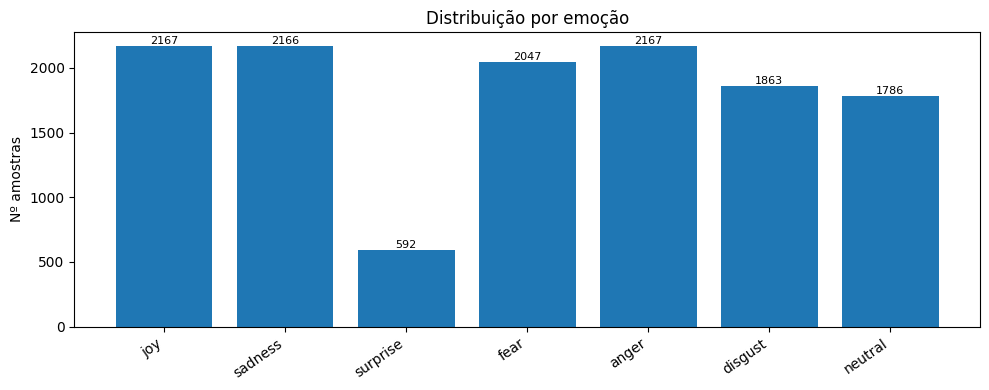

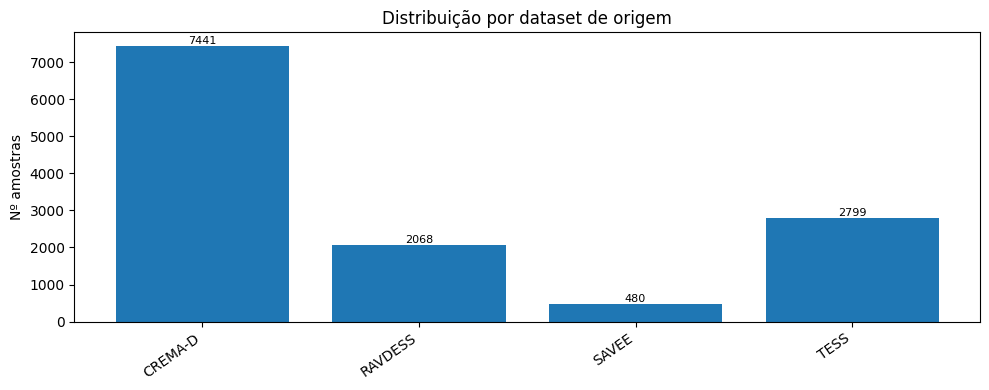

label,joy,sadness,surprise,fear,anger,disgust,neutral
source_dataset,,,,,,,
CREMA-D,1271,1270,0,1271,1271,1271,1087
RAVDESS,376,376,192,376,376,192,180
SAVEE,120,120,0,0,120,0,120
TESS,400,400,400,400,400,400,399


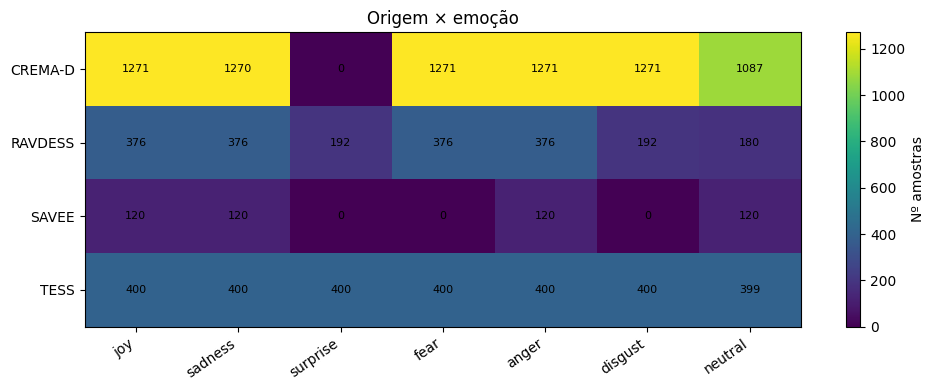

In [4]:
def bar_counts(series, title, order=None):
    counts = series.value_counts()
    if order is not None:
        counts = counts.reindex(order, fill_value=0)
    else:
        counts = counts.sort_index()
    plt.figure(figsize=(10,4))
    bars = plt.bar(counts.index.astype(str), counts.values)
    plt.title(title)
    plt.ylabel('Nº amostras')
    plt.xticks(rotation=35, ha='right')
    for b in bars:
        plt.text(b.get_x()+b.get_width()/2, b.get_height(), str(int(b.get_height())), ha='center', va='bottom', fontsize=8)
    plt.tight_layout(); plt.show()

bar_counts(metadata['label'], 'Distribuição por emoção', order=EMOTIONS)
bar_counts(metadata['source_dataset'], 'Distribuição por dataset de origem')

cross = pd.crosstab(metadata['source_dataset'], metadata['label']).reindex(columns=EMOTIONS, fill_value=0)
display(cross)
plt.figure(figsize=(10,4))
plt.imshow(cross.values, aspect='auto')
plt.title('Origem × emoção')
plt.yticks(range(len(cross.index)), cross.index)
plt.xticks(range(len(cross.columns)), cross.columns, rotation=35, ha='right')
plt.colorbar(label='Nº amostras')
for i in range(cross.shape[0]):
    for j in range(cross.shape[1]):
        plt.text(j, i, str(cross.values[i,j]), ha='center', va='center', fontsize=8)
plt.tight_layout(); plt.show()


## 5. Features manuais robustas

In [5]:

def safe_load_audio(path, sr=16000):
    y, sr = librosa.load(str(path), sr=sr, mono=True)
    y = np.asarray(y, dtype=np.float32)
    y = np.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0)
    if len(y) == 0:
        raise ValueError(f'Áudio vazio: {path}')
    return y, sr

def trim_silence(y, top_db=30):
    try:
        yt, _ = librosa.effects.trim(y, top_db=top_db)
        return yt.astype(np.float32) if len(yt) else y.astype(np.float32)
    except Exception:
        return y.astype(np.float32)

def stats(x, prefix):
    x = np.asarray(x, dtype=np.float64)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return {f'{prefix}_{k}':0.0 for k in ['mean','std','min','max','median','range','p10','p25','p75','p90','iqr']}
    p10,p25,p75,p90 = np.percentile(x, [10,25,75,90])
    return {
        f'{prefix}_mean':float(np.mean(x)), f'{prefix}_std':float(np.std(x)),
        f'{prefix}_min':float(np.min(x)), f'{prefix}_max':float(np.max(x)),
        f'{prefix}_median':float(np.median(x)), f'{prefix}_range':float(np.max(x)-np.min(x)),
        f'{prefix}_p10':float(p10), f'{prefix}_p25':float(p25), f'{prefix}_p75':float(p75),
        f'{prefix}_p90':float(p90), f'{prefix}_iqr':float(p75-p25)
    }

def segment_features(y, sr, prefix):
    if len(y) < int(0.1*sr):
        y = np.pad(y, (0, int(0.1*sr)-len(y)))
    feats = {f'{prefix}_duration': float(len(y)/sr)}
    rms = librosa.feature.rms(y=y)[0]
    zcr = librosa.feature.zero_crossing_rate(y)[0]
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
    flatness = librosa.feature.spectral_flatness(y=y)[0]
    onset = librosa.onset.onset_strength(y=y, sr=sr)
    for name, arr in [('rms',rms),('zcr',zcr),('centroid',centroid),('bandwidth',bandwidth),('rolloff',rolloff),('flatness',flatness),('onset',onset)]:
        feats.update(stats(arr, f'{prefix}_{name}'))
    feats[f'{prefix}_low_energy_ratio'] = float(np.mean(rms < np.mean(rms))) if len(rms) else 0.0
    try:
        tempo = librosa.feature.tempo(onset_envelope=onset, sr=sr)
        feats[f'{prefix}_tempo'] = float(tempo[0]) if len(tempo) else 0.0
    except Exception:
        feats[f'{prefix}_tempo'] = 0.0
    try:
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        for i in range(13):
            feats.update(stats(mfcc[i], f'{prefix}_mfcc{i+1}'))
    except Exception:
        for i in range(13): feats.update(stats([], f'{prefix}_mfcc{i+1}'))
    try:
        f0, vf, vp = librosa.pyin(y, fmin=50, fmax=500, sr=sr)
        f0v = f0[vf & np.isfinite(f0)] if f0 is not None else []
        feats.update(stats(f0v, f'{prefix}_f0'))
        feats[f'{prefix}_voiced_ratio'] = float(np.mean(vf)) if vf is not None and len(vf) else 0.0
        feats.update(stats(vp[np.isfinite(vp)] if vp is not None else [], f'{prefix}_voiced_prob'))
    except Exception:
        feats.update(stats([], f'{prefix}_f0'))
        feats[f'{prefix}_voiced_ratio'] = 0.0
        feats.update(stats([], f'{prefix}_voiced_prob'))
    return feats

def praat_features(y, sr):
    feats = {}
    if not HAS_PRAAT:
        return {'praat_f0_mean':0.0, 'praat_f0_std':0.0, 'jitter_local':0.0, 'shimmer_local':0.0}
    try:
        snd = parselmouth.Sound(y, sampling_frequency=sr)
        pitch = snd.to_pitch()
        f0 = pitch.selected_array['frequency']; f0 = f0[f0 > 0]
        feats.update(stats(f0, 'praat_f0'))
        pp = parselmouth.praat.call(snd, 'To PointProcess (periodic, cc)', 75, 500)
        jitter = parselmouth.praat.call(pp, 'Get jitter (local)', 0, 0, 0.0001, 0.02, 1.3)
        shimmer = parselmouth.praat.call([snd, pp], 'Get shimmer (local)', 0, 0, 0.0001, 0.02, 1.3, 1.6)
        feats['jitter_local'] = float(jitter) if np.isfinite(jitter) else 0.0
        feats['shimmer_local'] = float(shimmer) if np.isfinite(shimmer) else 0.0
    except Exception:
        feats.update({'praat_f0_mean':0.0, 'praat_f0_std':0.0, 'jitter_local':0.0, 'shimmer_local':0.0})
    return feats

def extract_manual_features(path, sr=16000, n_segments=4):
    y, sr = safe_load_audio(path, sr=sr)
    y = trim_silence(y)
    feats = {'duration_sec': float(len(y)/sr)}
    feats.update(segment_features(y, sr, 'global'))
    feats.update({f'global_{k}':v for k,v in praat_features(y, sr).items()})
    seg_len = max(1, len(y)//n_segments)
    for i in range(n_segments):
        start = i*seg_len
        end = len(y) if i == n_segments-1 else min(len(y), (i+1)*seg_len)
        feats.update(segment_features(y[start:end], sr, f'seg{i+1}'))
    for k in ['rms_mean','f0_mean','zcr_mean','centroid_mean','onset_mean','tempo']:
        feats[f'trend_{k}'] = float(feats.get(f'seg{n_segments}_{k}',0.0) - feats.get(f'seg1_{k}',0.0))
    return {k: (0.0 if not np.isfinite(v) else float(v)) for k,v in feats.items()}


## 6. Extrair/cache features manuais

In [6]:

manual_features_path = OUTPUT_DIR / 'manual_features_v5.csv'
manual_cols_path = OUTPUT_DIR / 'manual_feature_columns_v5.json'

if RUN_MANUAL_FEATURES:
    if USE_CACHE and manual_features_path.exists():
        manual_df = pd.read_csv(manual_features_path)
    else:
        rows=[]
        for row in tqdm(metadata.itertuples(index=False), total=len(metadata), desc='Features manuais'):
            try:
                feats = extract_manual_features(row.path)
                feats.update({'path': row.path, 'label': row.label, 'speaker': row.speaker, 'source_dataset': row.source_dataset})
                rows.append(feats)
            except Exception as e:
                print('Erro manual:', row.path, repr(e))
        manual_df = pd.DataFrame(rows)
        manual_df.to_csv(manual_features_path, index=False)
    manual_feature_cols = [c for c in manual_df.columns if c not in {'path','label','speaker','source_dataset'}]
    json.dump(manual_feature_cols, open(manual_cols_path,'w',encoding='utf-8'), ensure_ascii=False, indent=2)
    print('manual_df:', manual_df.shape, 'features:', len(manual_feature_cols))
else:
    manual_df = None
    manual_feature_cols = []


manual_df: (6899, 1254) features: 1250


## 7. Embeddings SSL com WavLM

In [7]:

import torch
from transformers import AutoFeatureExtractor, AutoModel
_SSL_CACHE={}

def device_name(): return 'cuda' if torch.cuda.is_available() else 'cpu'

def load_ssl_model(model_name=SSL_MODEL_NAME):
    if model_name in _SSL_CACHE: return _SSL_CACHE[model_name]
    device = device_name()
    print('A carregar', model_name, 'em', device)
    fe = AutoFeatureExtractor.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device)
    model.eval()
    _SSL_CACHE[model_name] = (fe, model, device)
    return _SSL_CACHE[model_name]

def iter_chunks(y, sr, max_seconds, overlap_seconds):
    max_len = int(max_seconds*sr); overlap = int(overlap_seconds*sr)
    if len(y) <= max_len:
        yield y; return
    step = max(1, max_len-overlap)
    start = 0
    while start < len(y):
        end = min(len(y), start+max_len)
        chunk = y[start:end]
        if len(chunk) > int(0.25*sr): yield chunk
        if end >= len(y): break
        start += step

def extract_ssl_embedding(path, model_name=SSL_MODEL_NAME, target_sr=SSL_SAMPLE_RATE):
    fe, model, device = load_ssl_model(model_name)
    y, sr = safe_load_audio(path, sr=target_sr)
    y = trim_silence(y)
    embs=[]
    for chunk in iter_chunks(y, sr, SSL_MAX_SECONDS_PER_CHUNK, SSL_CHUNK_OVERLAP_SECONDS):
        inputs = fe(chunk, sampling_rate=sr, return_tensors='pt', padding=True)
        inputs = {k:v.to(device) for k,v in inputs.items()}
        with torch.no_grad():
            out = model(**inputs)
            h = out.last_hidden_state.squeeze(0)
            mean = h.mean(dim=0).detach().cpu().numpy()
            std = h.std(dim=0).detach().cpu().numpy()
        embs.append(np.concatenate([mean,std]).astype(np.float32))
    if not embs: raise RuntimeError('Sem embedding SSL')
    # Mantém sempre 1536 dims: média entre chunks, não concatenação.
    return np.vstack(embs).mean(axis=0).astype(np.float32)


In [8]:

ssl_npz_path = OUTPUT_DIR / 'ssl_embeddings_v5_wavlm_base.npz'
ssl_meta_path = OUTPUT_DIR / 'ssl_embeddings_v5_wavlm_base_meta.csv'
ssl_cols_path = OUTPUT_DIR / 'ssl_feature_columns_v5.json'

if RUN_SSL_EMBEDDINGS:
    if USE_CACHE and ssl_npz_path.exists() and ssl_meta_path.exists():
        X_ssl = np.load(ssl_npz_path)['X_ssl']
        ssl_meta = pd.read_csv(ssl_meta_path)
    else:
        embs=[]; rows=[]
        for row in tqdm(metadata.itertuples(index=False), total=len(metadata), desc='WavLM'):
            try:
                embs.append(extract_ssl_embedding(row.path))
                rows.append({'path':row.path,'label':row.label,'speaker':row.speaker,'source_dataset':row.source_dataset})
            except Exception as e:
                print('Erro SSL:', row.path, repr(e))
        X_ssl = np.vstack(embs).astype(np.float32)
        ssl_meta = pd.DataFrame(rows)
        np.savez_compressed(ssl_npz_path, X_ssl=X_ssl)
        ssl_meta.to_csv(ssl_meta_path, index=False)
    ssl_feature_cols = [f'ssl_{i:04d}' for i in range(X_ssl.shape[1])]
    json.dump(ssl_feature_cols, open(ssl_cols_path,'w',encoding='utf-8'), ensure_ascii=False, indent=2)
    print('X_ssl:', X_ssl.shape)
else:
    X_ssl = None; ssl_meta=None; ssl_feature_cols=[]


WavLM:   0%|          | 0/12788 [00:00<?, ?it/s]

A carregar microsoft/wavlm-base em cpu


WavLM: 100%|██████████| 12788/12788 [49:24<00:00,  4.31it/s] 


X_ssl: (12788, 1536)


## 8. Alinhar matrizes

In [9]:

def align_tables():
    data = metadata[['path','filename','label','speaker','source_dataset']].copy()
    Xman = None
    if manual_df is not None:
        m = manual_df.drop_duplicates('path')
        data = data.merge(m[['path']+manual_feature_cols], on='path', how='inner')
        Xman = data[manual_feature_cols].to_numpy(dtype=np.float32)
    Xssl = None
    if ssl_meta is not None and X_ssl is not None:
        sm = ssl_meta.reset_index().rename(columns={'index':'ssl_idx'})
        data = data.merge(sm[['path','ssl_idx']], on='path', how='inner')
        Xssl = X_ssl[data['ssl_idx'].to_numpy()].astype(np.float32)
    return data, Xman, Xssl

aligned_df, X_manual, X_ssl_aligned = align_tables()
y_labels = aligned_df['label'].to_numpy()
groups = aligned_df['speaker'].to_numpy()
sources = aligned_df['source_dataset'].to_numpy()
label_to_idx = {e:i for i,e in enumerate(EMOTIONS)}
idx_to_label = {i:e for e,i in label_to_idx.items()}
y = np.array([label_to_idx[l] for l in y_labels], dtype=int)
class_priors = {e: float(np.mean(y_labels == e)) for e in EMOTIONS}
json.dump(class_priors, open(OUTPUT_DIR/'class_priors_v5.json','w',encoding='utf-8'), ensure_ascii=False, indent=2)

print('aligned:', aligned_df.shape)
print('X_manual:', None if X_manual is None else X_manual.shape)
print('X_ssl:', None if X_ssl_aligned is None else X_ssl_aligned.shape)
print('speakers:', len(np.unique(groups)), Counter(sources))


aligned: (0, 1256)
X_manual: (0, 1250)
X_ssl: (0, 1536)
speakers: 0 Counter()


## 9. Modelos e avaliação por speaker

In [15]:

def make_lr(C=1.0):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(C=C, max_iter=4000, class_weight='balanced', solver='lbfgs', n_jobs=-1, random_state=RANDOM_STATE))
    ])

def make_extra_trees(n_estimators=500):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', ExtraTreesClassifier(n_estimators=n_estimators, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, min_samples_leaf=2, max_features='sqrt'))
    ])

def make_rf(n_estimators=400):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', RandomForestClassifier(n_estimators=n_estimators, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, min_samples_leaf=2, max_features='sqrt'))
    ])

MODEL_CANDIDATES = {
    'lr_C0.3': make_lr(0.3),
    'lr_C1.0': make_lr(1.0),
    'extra_trees': make_extra_trees(500),
    # 'random_forest': make_rf(400),  # opcional; normalmente mais lento e menos forte que ExtraTrees
}

def normalize_proba(p):
    p = np.asarray(p, dtype=float)
    p = np.nan_to_num(p, nan=1/len(EMOTIONS), posinf=1/len(EMOTIONS), neginf=1/len(EMOTIONS))
    p = np.maximum(p, 1e-9)
    return p / p.sum(axis=1, keepdims=True)

def predict_proba_safe(model, X):
    if hasattr(model, 'predict_proba'):
        p = model.predict_proba(X)
        if hasattr(model, 'classes_') and len(model.classes_) != len(EMOTIONS):
            full = np.zeros((len(X), len(EMOTIONS)))
            for j,c in enumerate(model.classes_): full[:, int(c)] = p[:, j]
            p = full
        return normalize_proba(p)
    pred = model.predict(X)
    p = np.full((len(X), len(EMOTIONS)), 1e-3)
    p[np.arange(len(X)), pred] = 1.0
    return normalize_proba(p)

def collapse_penalty(pred):
    ratio = Counter(pred).most_common(1)[0][1] / len(pred)
    return max(0.0, ratio - 0.50)

def make_cv(y, groups, n_splits=N_SPLITS_GROUP_CV):
    n = min(n_splits, len(np.unique(groups)))
    try:
        return StratifiedGroupKFold(n_splits=n, shuffle=True, random_state=RANDOM_STATE)
    except Exception:
        return GroupKFold(n_splits=n)

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.base import clone
import numpy as np
import pandas as pd

def get_pipeline_classes(fitted_model):
    """
    Devolve as classes do classificador final, mesmo quando está dentro de Pipeline.
    """
    if hasattr(fitted_model, "classes_"):
        return list(fitted_model.classes_)

    if hasattr(fitted_model, "named_steps"):
        last_step = list(fitted_model.named_steps.values())[-1]
        if hasattr(last_step, "classes_"):
            return list(last_step.classes_)

    raise RuntimeError("Não consegui encontrar classes_ no modelo treinado.")


def predict_proba_aligned(fitted_model, X_test, emotions):
    """
    Garante que as probabilidades ficam sempre na ordem EMOTIONS:
    ['joy','sadness','surprise','fear','anger','disgust','neutral']
    """
    proba_raw = fitted_model.predict_proba(X_test)
    model_classes = get_pipeline_classes(fitted_model)

    out = np.zeros((X_test.shape[0], len(emotions)), dtype=np.float32)

    for j, cls in enumerate(model_classes):
        if cls in emotions:
            out[:, emotions.index(cls)] = proba_raw[:, j]

    # normalizar por segurança
    row_sums = out.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    out = out / row_sums

    return out


def evaluate_cv(model_name, model, X, y, groups, feature_set):
    """
    Avaliação com StratifiedGroupKFold.
    Corrigido para labels em string, como 'anger', 'joy', etc.
    """
    y = np.asarray(y).astype(str)
    groups = np.asarray(groups).astype(str)

    n_groups = len(np.unique(groups))
    n_splits = min(N_SPLITS_GROUP_CV, n_groups)

    if n_splits < 2:
        raise ValueError(
            f"Não há grupos suficientes para CV. n_groups={n_groups}, n_splits={n_splits}"
        )

    cv = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    # IMPORTANTE: dtype=object para aceitar strings como 'anger'
    oof_pred = np.empty(len(y), dtype=object)
    oof_proba = np.zeros((len(y), len(EMOTIONS)), dtype=np.float32)

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups)):
        clf = clone(model)

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        clf.fit(X_train, y_train)

        pred = clf.predict(X_test)
        proba = predict_proba_aligned(clf, X_test, EMOTIONS)

        oof_pred[test_idx] = pred
        oof_proba[test_idx] = proba

        print(
            f"  fold {fold+1}/{n_splits} | "
            f"test={len(test_idx)} | "
            f"acc={accuracy_score(y_test, pred):.4f} | "
            f"f1_macro={f1_score(y_test, pred, average='macro'):.4f}"
        )

    acc = accuracy_score(y, oof_pred)
    bal_acc = balanced_accuracy_score(y, oof_pred)
    f1_macro = f1_score(y, oof_pred, average="macro")
    f1_weighted = f1_score(y, oof_pred, average="weighted")

    pred_counts = pd.Series(oof_pred).value_counts(normalize=True)
    max_pred_ratio = float(pred_counts.max())

    # Penalização simples contra colapso de classe
    collapse_penalty = max(0.0, max_pred_ratio - 0.45)
    score_adjusted = f1_macro - collapse_penalty

    return {
        "feature_set": feature_set,
        "model_name": model_name,
        "n_samples": len(y),
        "n_groups": n_groups,
        "n_splits": n_splits,
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "max_pred_ratio": max_pred_ratio,
        "collapse_penalty": collapse_penalty,
        "score_adjusted": score_adjusted,
        "oof_pred": oof_pred,
        "oof_proba": oof_proba,
    }


from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.base import clone
import numpy as np
import pandas as pd

def leave_one_source_out(model_name, model, X, y, sources, feature_set):
    """
    Avaliação Leave-One-Source-Out:
    treina em todos os datasets menos um e testa no dataset deixado de fora.
    """
    y = np.asarray(y).astype(str)
    sources = np.asarray(sources).astype(str)

    rows = []

    for heldout_source in sorted(np.unique(sources)):
        train_idx = np.where(sources != heldout_source)[0]
        test_idx = np.where(sources == heldout_source)[0]

        if len(train_idx) == 0 or len(test_idx) == 0:
            continue

        clf = clone(model)
        clf.fit(X[train_idx], y[train_idx])

        pred = clf.predict(X[test_idx])

        rows.append({
            "feature_set": feature_set,
            "model_name": model_name,
            "heldout_source": heldout_source,
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            "accuracy": accuracy_score(y[test_idx], pred),
            "balanced_accuracy": balanced_accuracy_score(y[test_idx], pred),
            "f1_macro": f1_score(y[test_idx], pred, average="macro"),
            "f1_weighted": f1_score(y[test_idx], pred, average="weighted"),
            "pred_distribution": dict(pd.Series(pred).value_counts()),
        })

    return pd.DataFrame(rows)


In [16]:
from pathlib import Path
import json
import numpy as np
import pandas as pd

OUTPUT_DIR = Path("prosody_outputs_v5")

EMOTIONS = ["joy", "sadness", "surprise", "fear", "anger", "disgust", "neutral"]

FOLDER_LABEL_MAP = {
    "Angry": "anger",
    "Happy": "joy",
    "Sad": "sadness",
    "Neutral": "neutral",
    "Fearful": "fear",
    "Disgusted": "disgust",
    "Surprised": "surprise",
    "Suprised": "surprise",

    "angry": "anger",
    "happy": "joy",
    "sad": "sadness",
    "neutral": "neutral",
    "fearful": "fear",
    "disgusted": "disgust",
    "surprised": "surprise",
    "suprised": "surprise",
}

def make_rel_key_from_path(path_value):
    """
    Cria uma chave estável tipo 'Angry/ficheiro.wav' ou 'Suprised/ficheiro.wav',
    mesmo que o caminho absoluto tenha mudado.
    """
    p = Path(str(path_value))
    parts = list(p.parts)

    if "Emotions" in parts:
        i = parts.index("Emotions")
        if len(parts) > i + 2:
            return f"{parts[i+1]}/{p.name}"

    return f"{p.parent.name}/{p.name}"

def add_rel_key(df):
    df = df.copy()

    if "path" in df.columns:
        df["rel_key"] = df["path"].apply(make_rel_key_from_path)
    elif "folder" in df.columns and "filename" in df.columns:
        df["rel_key"] = df["folder"].astype(str) + "/" + df["filename"].astype(str)
    elif "filename" in df.columns:
        raise RuntimeError("Tenho filename mas não tenho path/folder para criar rel_key.")
    else:
        raise RuntimeError("Não encontro colunas suficientes para criar rel_key.")

    return df

def load_json_list(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

print("A carregar ficheiros já existentes em:", OUTPUT_DIR.resolve())

metadata_path = OUTPUT_DIR / "metadata_v5_clean.csv"
manual_path = OUTPUT_DIR / "manual_features_v5.csv"
manual_cols_path = OUTPUT_DIR / "manual_feature_columns_v5.json"
ssl_npz_path = OUTPUT_DIR / "ssl_embeddings_v5_wavlm_base.npz"
ssl_meta_path = OUTPUT_DIR / "ssl_embeddings_v5_wavlm_base_meta.csv"

for p in [manual_path, manual_cols_path, ssl_npz_path, ssl_meta_path]:
    print(p.name, "existe?", p.exists())

if not manual_path.exists():
    raise FileNotFoundError(manual_path)
if not ssl_npz_path.exists():
    raise FileNotFoundError(ssl_npz_path)
if not ssl_meta_path.exists():
    raise FileNotFoundError(ssl_meta_path)

manual_cols = load_json_list(manual_cols_path)
manual_df = pd.read_csv(manual_path)
manual_df = add_rel_key(manual_df)

print("\nmanual_df:", manual_df.shape)
print("manual_cols:", len(manual_cols))

# Se o manual_features já tiver label/speaker/source_dataset, usamos isso como base.
needed_meta_cols = {"label", "speaker", "source_dataset"}
if needed_meta_cols.issubset(set(manual_df.columns)):
    base_df = manual_df.copy()
    print("✅ A usar label/speaker/source_dataset diretamente de manual_features_v5.csv")
else:
    print("manual_features não tem metadata completo. Vou tentar juntar com metadata_v5_clean.csv.")
    if not metadata_path.exists():
        raise FileNotFoundError(metadata_path)

    metadata = pd.read_csv(metadata_path)
    metadata = add_rel_key(metadata)

    print("metadata:", metadata.shape)

    if metadata.empty:
        raise RuntimeError(
            "metadata_v5_clean.csv está vazio. Tens de reconstruir apenas metadata, "
            "mas não precisas de recalcular as features."
        )

    base_df = metadata[["rel_key", "label", "speaker", "source_dataset"]].merge(
        manual_df,
        on="rel_key",
        how="inner"
    )

print("base_df depois do alinhamento manual:", base_df.shape)

# Limpeza defensiva
base_df = base_df[base_df["label"].isin(EMOTIONS)].copy()
base_df = base_df[~base_df["source_dataset"].eq("unknown")].copy()
base_df = base_df[~base_df["speaker"].eq("unknown")].copy()

print("base_df depois da limpeza:", base_df.shape)
print("\nDistribuição por emoção:")
display(base_df["label"].value_counts().reindex(EMOTIONS, fill_value=0).to_frame("n"))

if base_df.empty:
    raise RuntimeError("base_df ficou vazio. O problema está no alinhamento entre metadata e manual_features.")

missing_manual_cols = [c for c in manual_cols if c not in base_df.columns]
if missing_manual_cols:
    raise RuntimeError(f"Faltam colunas manuais em base_df. Exemplos: {missing_manual_cols[:20]}")

# Carregar embeddings SSL
ssl_meta = pd.read_csv(ssl_meta_path)
ssl_meta = add_rel_key(ssl_meta)

z = np.load(ssl_npz_path, allow_pickle=True)
print("\nNPZ keys:", z.files)


if "X_ssl" in z.files:
    ssl_emb = z["X_ssl"]
elif "embeddings" in z.files:
    ssl_emb = z["embeddings"]
elif "X" in z.files:
    ssl_emb = z["X"]
elif "arr_0" in z.files:
    ssl_emb = z["arr_0"]
else:
    raise RuntimeError(f"Não encontrei matriz de embeddings no npz. Keys: {z.files}")


print("ssl_emb:", ssl_emb.shape)
print("ssl_meta:", ssl_meta.shape)

if len(ssl_meta) != ssl_emb.shape[0]:
    raise RuntimeError(
        f"ssl_meta tem {len(ssl_meta)} linhas, mas ssl_emb tem {ssl_emb.shape[0]} embeddings."
    )

ssl_meta = ssl_meta.reset_index(drop=True)
ssl_meta["ssl_row"] = np.arange(len(ssl_meta))

# Alinhar manual + SSL por rel_key
aligned = base_df.merge(
    ssl_meta[["rel_key", "ssl_row"]],
    on="rel_key",
    how="inner"
)

print("\naligned manual + ssl:", aligned.shape)

if aligned.empty:
    print("⚠️ Alinhamento por rel_key deu 0. Vou tentar por filename como fallback.")
    ssl_meta_filename = ssl_meta.copy()
    if "filename" not in ssl_meta_filename.columns:
        ssl_meta_filename["filename"] = ssl_meta_filename["rel_key"].apply(lambda x: str(x).split("/")[-1])

    base_filename = base_df.copy()
    if "filename" not in base_filename.columns:
        base_filename["filename"] = base_filename["rel_key"].apply(lambda x: str(x).split("/")[-1])

    aligned = base_filename.merge(
        ssl_meta_filename[["filename", "ssl_row"]],
        on="filename",
        how="inner"
    )

    print("aligned por filename:", aligned.shape)

if aligned.empty:
    raise RuntimeError("Não consegui alinhar manual_features com ssl_embeddings. Preciso ver as colunas dos CSVs.")

# Construir matrizes finais
X_manual = aligned[manual_cols].to_numpy(dtype=np.float32)
X_ssl_aligned = ssl_emb[aligned["ssl_row"].to_numpy()].astype(np.float32)

y = aligned["label"].to_numpy()
groups = aligned["speaker"].astype(str).to_numpy()
sources = aligned["source_dataset"].astype(str).to_numpy()

print("\n✅ Matrizes reconstruídas:")
print("X_manual:", X_manual.shape)
print("X_ssl_aligned:", X_ssl_aligned.shape)
print("y:", y.shape)
print("groups:", groups.shape, "n_unique:", len(np.unique(groups)))
print("sources:", sources.shape, "n_unique:", len(np.unique(sources)))

print("\nLabels finais:")
print(pd.Series(y).value_counts().reindex(EMOTIONS, fill_value=0))

if X_manual.shape[0] == 0 or X_ssl_aligned.shape[0] == 0 or len(y) == 0:
    raise RuntimeError("Ainda há 0 linhas. Não avances para o treino.")

if len(np.unique(groups)) < 2:
    raise RuntimeError("Há menos de 2 speakers/grupos. Não dá para GroupKFold.")

feature_matrices = {
    "manual": X_manual,
    "ssl_wavlm": X_ssl_aligned,
    "manual_plus_ssl": np.hstack([X_manual, X_ssl_aligned]).astype(np.float32)
}

print("\nfeature_matrices:")
for k, v in feature_matrices.items():
    print(k, v.shape)

A carregar ficheiros já existentes em: /home/tomas/MIA/1ANO/2SEM/CA/CA-25_26/tests/prosody/prosody_outputs_v5
manual_features_v5.csv existe? True
manual_feature_columns_v5.json existe? True
ssl_embeddings_v5_wavlm_base.npz existe? True
ssl_embeddings_v5_wavlm_base_meta.csv existe? True

manual_df: (6899, 1255)
manual_cols: 1250
✅ A usar label/speaker/source_dataset diretamente de manual_features_v5.csv
base_df depois do alinhamento manual: (6899, 1255)
base_df depois da limpeza: (6899, 1255)

Distribuição por emoção:


,n
label,
joy,822
sadness,0
surprise,0
fear,2047
anger,2167
disgust,1863
neutral,0



NPZ keys: ['X_ssl']
ssl_emb: (12788, 1536)
ssl_meta: (12788, 5)

aligned manual + ssl: (6899, 1256)

✅ Matrizes reconstruídas:
X_manual: (6899, 1250)
X_ssl_aligned: (6899, 1536)
y: (6899,)
groups: (6899,) n_unique: 118
sources: (6899,) n_unique: 4

Labels finais:
joy          822
sadness        0
surprise       0
fear        2047
anger       2167
disgust     1863
neutral        0
Name: count, dtype: int64

feature_matrices:
manual (6899, 1250)
ssl_wavlm (6899, 1536)
manual_plus_ssl (6899, 2786)


## 10. Benchmark

In [ ]:

feature_matrices = {}
if X_manual is not None: feature_matrices['manual'] = X_manual
if X_ssl_aligned is not None: feature_matrices['ssl_wavlm'] = X_ssl_aligned
if X_manual is not None and X_ssl_aligned is not None:
    feature_matrices['manual_plus_ssl'] = np.hstack([X_manual, X_ssl_aligned]).astype(np.float32)

results=[]; oof_store={}; source_tables=[]
for fs, X in feature_matrices.items():
    print('\n' + '='*90); print('FEATURE SET:', fs, X.shape); print('='*90)
    for mn, model in MODEL_CANDIDATES.items():
        t0=time.time()
        try:
            res = evaluate_cv(mn, model, X, y, groups, fs)
            row = {k:v for k,v in res.items() if k not in {'oof_pred','oof_proba'}}
            row['elapsed_sec'] = time.time()-t0
            results.append(row)
            oof_store[(fs,mn)] = {'pred': res['oof_pred'], 'proba': res['oof_proba']}
            if mn.startswith('lr'):
                source_tables.append(leave_one_source_out(mn, model, X, y, sources, fs))
        except Exception as e:
            print('Erro:', fs, mn, repr(e))

benchmark_df = pd.DataFrame(results).sort_values('score_adjusted', ascending=False)
benchmark_df.to_csv(OUTPUT_DIR/'prosody_model_benchmark_v5.csv', index=False)
display(benchmark_df)

if source_tables:
    source_eval_df = pd.concat(source_tables, ignore_index=True)
    source_eval_df.to_csv(OUTPUT_DIR/'leave_one_source_out_v5.csv', index=False)
    display(source_eval_df.sort_values(['feature_set','model_name','heldout_source']))



FEATURE SET: manual (6899, 1250)
  fold 1/5 | test=742 | acc=0.6119 | f1_macro=0.6070
  fold 2/5 | test=820 | acc=0.5646 | f1_macro=0.5448
  fold 3/5 | test=1899 | acc=0.6740 | f1_macro=0.6274
  fold 4/5 | test=1982 | acc=0.6418 | f1_macro=0.6287
  fold 5/5 | test=1456 | acc=0.6470 | f1_macro=0.6334
  fold 1/5 | test=742 | acc=0.6065 | f1_macro=0.6020
  fold 2/5 | test=820 | acc=0.5780 | f1_macro=0.5538
  fold 3/5 | test=1899 | acc=0.6577 | f1_macro=0.6102
  fold 4/5 | test=1982 | acc=0.6140 | f1_macro=0.6000
  fold 5/5 | test=1456 | acc=0.6435 | f1_macro=0.6313
  fold 1/5 | test=742 | acc=0.6146 | f1_macro=0.5958
  fold 2/5 | test=820 | acc=0.5512 | f1_macro=0.5381
  fold 3/5 | test=1899 | acc=0.6746 | f1_macro=0.6390
  fold 4/5 | test=1982 | acc=0.6448 | f1_macro=0.6000
  fold 5/5 | test=1456 | acc=0.6518 | f1_macro=0.6271

FEATURE SET: ssl_wavlm (6899, 1536)
  fold 1/5 | test=742 | acc=0.7466 | f1_macro=0.7408
  fold 2/5 | test=820 | acc=0.6341 | f1_macro=0.6275
  fold 3/5 | test=1

## 11. Melhor modelo e matriz de confusão

In [ ]:
best = benchmark_df.iloc[0].to_dict()
best_key = (best['feature_set'], best['model_name'])
print('Melhor:', best_key)
print(best)

pred = oof_store[best_key]['pred']
print(classification_report(y, pred, labels=list(range(len(EMOTIONS))), target_names=EMOTIONS, digits=4, zero_division=0))
cm = confusion_matrix(y, pred, labels=list(range(len(EMOTIONS))))
plt.figure(figsize=(8,7))
plt.imshow(cm)
plt.title(f'Matriz de confusão — {best_key[0]} / {best_key[1]}')
plt.xticks(range(len(EMOTIONS)), EMOTIONS, rotation=35, ha='right')
plt.yticks(range(len(EMOTIONS)), EMOTIONS)
plt.xlabel('Classe prevista'); plt.ylabel('Classe real')
plt.colorbar(label='Nº amostras')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]): plt.text(j,i,str(cm[i,j]),ha='center',va='center')
plt.tight_layout(); plt.savefig(OUTPUT_DIR/'best_confusion_matrix_v5.png', dpi=160); plt.show()

pred_counts = pd.Series([idx_to_label[i] for i in pred]).value_counts().reindex(EMOTIONS, fill_value=0)
plt.figure(figsize=(9,4)); plt.bar(pred_counts.index, pred_counts.values)
plt.title(f'Distribuição de previsões OOF — {best_key[0]} / {best_key[1]}')
plt.xticks(rotation=35, ha='right')
for i,v in enumerate(pred_counts.values): plt.text(i,v,str(int(v)),ha='center',va='bottom')
plt.tight_layout(); plt.savefig(OUTPUT_DIR/'best_prediction_distribution_v5.png', dpi=160); plt.show()


## 12. Ensemble manual + SSL

In [ ]:
def weighted_average(probas, weights):
    w = np.asarray(weights, dtype=float); w = w/(w.sum()+1e-9)
    out = np.zeros_like(probas[0])
    for p, wi in zip(probas, w): out += wi*p
    return normalize_proba(out)

benchmark_df2 = benchmark_df.copy()
ensemble_info = None
manual_rows = [r for r in results if r['feature_set'] == 'manual']
ssl_rows = [r for r in results if r['feature_set'] == 'ssl_wavlm']
if manual_rows and ssl_rows:
    bm = sorted(manual_rows, key=lambda r:r['score_adjusted'], reverse=True)[0]
    bs = sorted(ssl_rows, key=lambda r:r['score_adjusted'], reverse=True)[0]
    km = (bm['feature_set'], bm['model_name']); ks = (bs['feature_set'], bs['model_name'])
    wm = max(0.01, bm['f1_macro']); ws = max(0.01, bs['f1_macro'])
    p_ens = weighted_average([oof_store[km]['proba'], oof_store[ks]['proba']], [wm, ws])
    pred_ens = p_ens.argmax(axis=1)
    ens = {'feature_set':'ensemble_manual_ssl','model_name':f"{km[1]}+{ks[1]}",
           'accuracy':accuracy_score(y,pred_ens),'balanced_accuracy':balanced_accuracy_score(y,pred_ens),
           'f1_macro':f1_score(y,pred_ens,average='macro'),'f1_weighted':f1_score(y,pred_ens,average='weighted'),
           'collapse_penalty':collapse_penalty(pred_ens), 'manual_weight':wm/(wm+ws), 'ssl_weight':ws/(wm+ws)}
    ens['score_adjusted'] = ens['f1_macro'] - ens['collapse_penalty']
    ensemble_info = {'best_manual':bm, 'best_ssl':bs, 'ensemble':ens}
    benchmark_df2 = pd.concat([benchmark_df, pd.DataFrame([ens])], ignore_index=True).sort_values('score_adjusted', ascending=False)
    benchmark_df2.to_csv(OUTPUT_DIR/'prosody_model_benchmark_v5_with_ensemble.csv', index=False)
    print('Ensemble:', ens)
    print(classification_report(y, pred_ens, labels=list(range(len(EMOTIONS))), target_names=EMOTIONS, digits=4, zero_division=0))
    display(benchmark_df2)
else:
    print('Ensemble não disponível: falta ramo manual ou SSL.')


## 13. Treino final e exportação do artefacto

In [ ]:

def fit_final(feature_set, model_name):
    m = clone(MODEL_CANDIDATES[model_name])
    m.fit(feature_matrices[feature_set], y)
    return m

best_final = benchmark_df2.iloc[0].to_dict()
print('Best final:', best_final)

artifact = {
    'version': 'prosody_v5_kaggle_emotions_advanced',
    'emotions': EMOTIONS,
    'label_to_idx': label_to_idx,
    'idx_to_label': idx_to_label,
    'class_priors': class_priors,
    'dataset_dir': str(DATASET_DIR.resolve()),
    'ssl_model_name': SSL_MODEL_NAME,
    'ssl_sample_rate': SSL_SAMPLE_RATE,
    'manual_feature_cols': manual_feature_cols,
    'ssl_feature_cols': ssl_feature_cols,
    'benchmark': benchmark_df2.to_dict(orient='records'),
    'selected_score': best_final,
}

if best_final['feature_set'] == 'ensemble_manual_ssl' and ensemble_info is not None:
    bm = ensemble_info['best_manual']; bs = ensemble_info['best_ssl']; ens = ensemble_info['ensemble']
    artifact.update({
        'selected_strategy': 'ensemble_manual_ssl',
        'manual_model_name': bm['model_name'],
        'ssl_model_name_clf': bs['model_name'],
        'manual_model': fit_final('manual', bm['model_name']),
        'ssl_model': fit_final('ssl_wavlm', bs['model_name']),
        'manual_weight': float(ens['manual_weight']),
        'ssl_weight': float(ens['ssl_weight']),
    })
else:
    fs = best_final['feature_set']; mn = best_final['model_name']
    artifact.update({'selected_strategy': fs, 'final_model_name': mn, 'final_model': fit_final(fs, mn)})

artifact_path = OUTPUT_DIR/'prosody_final_artifact_v5.joblib'
joblib.dump(artifact, artifact_path)
print('Guardado:', artifact_path.resolve())
print('Estratégia:', artifact['selected_strategy'])


## 14. Inferência com o artefacto v5

In [ ]:

def entropy_confidence(p):
    p = np.asarray(p, dtype=float); p = np.maximum(p,1e-9); p = p/p.sum()
    return float(1.0 - (-np.sum(p*np.log(p)) / np.log(len(p))))

def smooth_with_priors(p, priors, alpha=0.02):
    prior = np.array([priors[e] for e in EMOTIONS], dtype=float); prior = prior/prior.sum()
    p = (1-alpha)*np.asarray(p,dtype=float) + alpha*prior
    return p/p.sum()

def proba_to_dist(p): return {e: round(float(p[i]),4) for i,e in enumerate(EMOTIONS)}

def classify_prosody_audio_v5(audio_path, artifact_path=artifact_path):
    art = joblib.load(artifact_path)
    strategy = art['selected_strategy']
    manual_x = None; ssl_x = None
    if strategy in {'manual','manual_plus_ssl','ensemble_manual_ssl'}:
        feats = extract_manual_features(audio_path)
        manual_x = pd.DataFrame([{c:feats.get(c,0.0) for c in art['manual_feature_cols']}]).to_numpy(dtype=np.float32)
    if strategy in {'ssl_wavlm','manual_plus_ssl','ensemble_manual_ssl'}:
        ssl_x = extract_ssl_embedding(audio_path, art['ssl_model_name'], art['ssl_sample_rate']).reshape(1,-1)
    if strategy == 'manual':
        p = predict_proba_safe(art['final_model'], manual_x)[0]; internal={'manual':1.0}
    elif strategy == 'ssl_wavlm':
        p = predict_proba_safe(art['final_model'], ssl_x)[0]; internal={'ssl':1.0}
    elif strategy == 'manual_plus_ssl':
        p = predict_proba_safe(art['final_model'], np.hstack([manual_x, ssl_x]))[0]; internal={'manual_plus_ssl':1.0}
    elif strategy == 'ensemble_manual_ssl':
        pm = predict_proba_safe(art['manual_model'], manual_x)[0]
        ps = predict_proba_safe(art['ssl_model'], ssl_x)[0]
        wm = art.get('manual_weight',0.5); ws = art.get('ssl_weight',0.5)
        p = weighted_average([pm.reshape(1,-1), ps.reshape(1,-1)], [wm, ws])[0]
        internal={'manual':round(float(wm),4), 'ssl':round(float(ws),4)}
    else:
        raise RuntimeError(f'Estratégia desconhecida: {strategy}')
    p = smooth_with_priors(p, art['class_priors'], alpha=0.02)
    dominant = EMOTIONS[int(np.argmax(p))]
    dist = proba_to_dist(p)
    return {'audio_path':str(audio_path),'dominant_emotion':dominant,'distribution':dist,
            'ranking':sorted(dist.items(), key=lambda x:x[1], reverse=True),
            'confidence_entropy':round(entropy_confidence(p),4),'strategy':strategy,'internal_weights':internal}


## 15. Teste nos teus áudios reais

In [ ]:

REAL_AUDIO_DIR = Path('/home/tomas/MIA/1ANO/2SEM/CA/CA-25_26/tests/final')
if REAL_AUDIO_DIR.exists():
    files = sorted(REAL_AUDIO_DIR.glob('*.wav'))
    rows=[]
    for p in files:
        print('\n' + '='*80); print('🎙️', p.name)
        try:
            r = classify_prosody_audio_v5(p, artifact_path)
            expected = p.stem.lower().replace('sad','sadness').replace('happy','joy')
            print('Esperado:', expected)
            print('Prosódia:', r['dominant_emotion'])
            print('Distribuição:', r['distribution'])
            print('Estratégia:', r['strategy'], r['internal_weights'])
            rows.append({'file':p.name,'expected':expected,'prosody_emotion':r['dominant_emotion'],
                         'correct':expected==r['dominant_emotion'],'confidence_entropy':r['confidence_entropy'],
                         **{f'prosody_{e}': r['distribution'][e] for e in EMOTIONS}})
        except Exception as e:
            print('Erro:', repr(e))
    if rows:
        real_results = pd.DataFrame(rows)
        display(real_results)
        real_results.to_csv(OUTPUT_DIR/'real_audio_test_results_v5.csv', index=False)
        print('Accuracy real:', real_results['correct'].mean())
else:
    print('REAL_AUDIO_DIR não existe. Ajusta o caminho.')


## 16. Integração com o notebook multimodal

Depois de correres este notebook, atualiza no multimodal:

```python
PROSODY_MODEL_PATH = Path("prosody_outputs_v5/prosody_final_artifact_v5.joblib")
```

O mais importante é verificares se, nos teus 7 áudios reais, a prosódia deixa de prever sempre `fear`. Se continuar a acontecer, mantém a fusão segura do multimodal v5 e explica o problema como **domain shift** entre datasets emocionais atuados e diários reais naturais.
